In [218]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [219]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
base_path = Path('/content/drive/MyDrive/Dane_solvro_wyzwanie/titanic.csv')
sns.set_palette("ch:s=-.2,r=.6")

# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

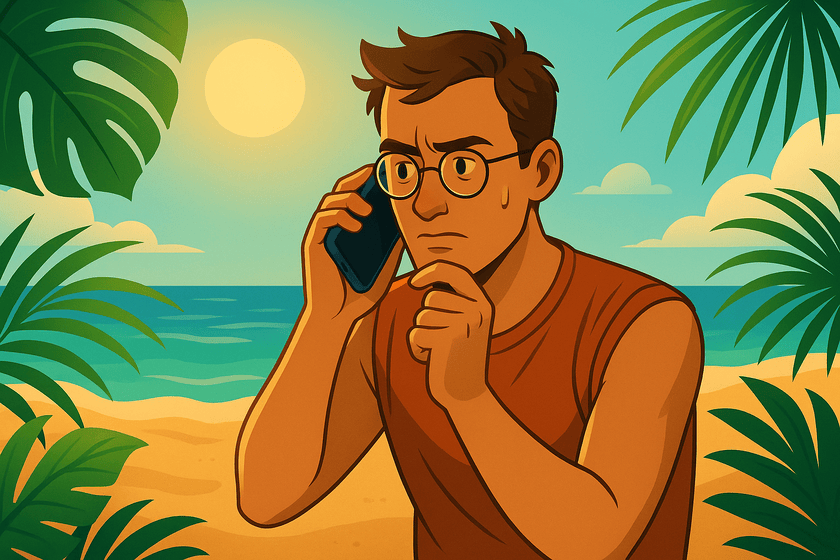

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [220]:
titanic_df = pd.read_csv(base_path, index_col='PassengerId')

In [221]:
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


W kontekście szukania cech pomagających w identyfikacji pasażera Titanica jako ofiary lub osoby, która przeżyła, kolumny PassageID oraz Ticket są niepotrzebne. Są to swego rodzaju identyfikatory, które nie zapewniają dodatkowych informacji o grupie.


In [222]:
titanic_df = titanic_df.drop(columns="Ticket")

In [223]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      793 non-null    float64
 8   Cabin     204 non-null    object 
 9   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 76.6+ KB


In [224]:
titanic_df['Sex'] = titanic_df['Sex'].astype('category')
titanic_df['Embarked'] = titanic_df['Embarked'].astype('category')
titanic_df['Pclass'] = titanic_df['Pclass'].astype('category')

In [225]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    int64   
 1   Pclass    891 non-null    category
 2   Name      891 non-null    object  
 3   Sex       891 non-null    category
 4   Age       714 non-null    float64 
 5   SibSp     891 non-null    int64   
 6   Parch     891 non-null    int64   
 7   Fare      793 non-null    float64 
 8   Cabin     204 non-null    object  
 9   Embarked  889 non-null    category
dtypes: category(3), float64(2), int64(3), object(2)
memory usage: 58.7+ KB


Kolumny Pclass, Sex, Embarked zawierają dane kategorialne. Dane w kolumnie Survived również można zaliczyć do kategorialnych jednak tutaj warto zostawić to jako int64, aby przy grupowaniu móc obliczyć średnią wartość. Pozostałe kolumny są numeryczne - prawidłowo dopasowane typy danych.

In [226]:
titanic_df.Survived.value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


Predykowaną klasą jest zmienna Survived. Widoczna jest pewna dysproporcja w danych - około 61.6% pasażerów nie przeżyło katastrofy (Survived = 0), a 38.4% przetrwało.

In [227]:
titanic_df.isna().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,98
Cabin,687
Embarked,2


Wartości brakujące znajdują się w 4 kolumnach: Age, Fare, Cabin, Embarked.

In [228]:
def get_percentage_missing(df, axis):
  missing = titanic_df.isna().sum(axis=axis)
  missing_perc = np.round(missing / df.shape[axis] * 100, 2)
  return missing_perc

In [229]:
get_percentage_missing(titanic_df, 0)

,0
Survived,0.00
Pclass,0.00
Name,0.00
Sex,0.00
Age,19.87
SibSp,0.00
Parch,0.00
Fare,11.00
Cabin,77.10
Embarked,0.22


Najwięcej wartości brakujących jest w kolumnie Cabin - 77.10% - usuwanie rekordów z brakami w takim przypadku byłoby bez sensu, bo w ten sposób usuniętoby większość zbioru danych. Trudno uzupełnić te wartości, dlatego dane zostaną podzielone na posiadaczy przypisanej kabiny (1) oraz pasażerów bez kabiny (0).

In [230]:
titanic_df['owns_Cabin'] = titanic_df['Cabin'].notna().astype('int')
titanic_df = titanic_df.drop(columns="Cabin")

W kolumnie Embarked występują tylko 2 braki danych, więc rozsądne wydaje się uzupełnienie ich wartością najczęstszą.

In [231]:
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])

W przypadku braków danych w kolumnie Fare, można je uzupełnić medianami wartościami, biorąc pod uwagę kolumnę Pclass (cena biletu w pierwszej klasie będzie wyższa niż pozostałe; poza tym w kolumnie Pclass nie ma braków danych)

In [232]:
titanic_df.groupby('Pclass').Fare.mean()

/tmp/ipykernel_1633/3361884097.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic_df.groupby('Pclass').Fare.mean()


,Fare
Pclass,
1,86.771177
2,20.489127
3,13.886074


In [233]:
titanic_df['Fare'] = titanic_df['Fare'].fillna(titanic_df.groupby('Pclass', observed=False).Fare.transform("median"))

W przypadku ostatniej kolumny zawierającej braki - Age - można z kolumny Name "wyciągnąć" tytuł pasażera, a braki uzupełnić medianami wieku w danych kategoriach (średnia jest mniej odporna na wartości odstające).

In [234]:
titanic_df['Age_title'] = titanic_df['Name'].apply(lambda x: x.split(",")[1].split(".")[0].strip())

# x.split(",")[1] zwraca wszystko co mam po przecinku
# .splot(".")[0] zwraca to co jest przed kropką
# .strip() usuwa spacje

In [235]:
titanic_df["Age"] = titanic_df['Age'].fillna(titanic_df.groupby("Age_title").Age.transform("median"))

Po wyciągnięciu z kolumny Name informacji o tytule pasażera, tę kolumnę także można usunąć (jest już tylko identyfikatorem jak jak było wcześniej z PassengerID oraz Ticket)

In [236]:
titanic_df = titanic_df.drop(columns="Name")

In [237]:
get_percentage_missing(titanic_df, 0)

,0
Survived,0.0
Pclass,0.0
Sex,0.0
Age,0.0
SibSp,0.0
Parch,0.0
Fare,0.0
Embarked,0.0
owns_Cabin,0.0
Age_title,0.0


In [238]:
def plot_numeric_histogram(df, column_name):
    data = df[column_name]
    mean_val = data.mean()
    median_val = data.median()

    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=30, color='steelblue', edgecolor='black')
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

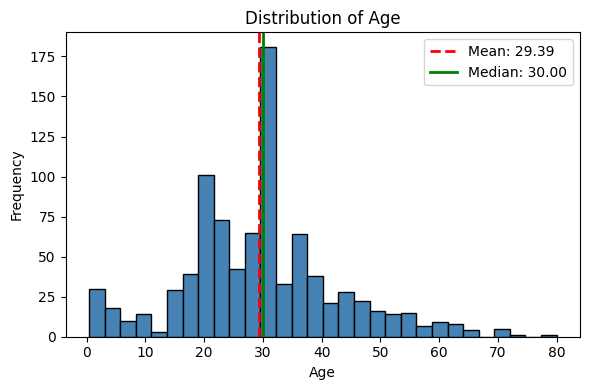

In [239]:
plot_numeric_histogram(titanic_df, "Age")

Obserwując histogram zmiennej Age można stwierdzić, że zmienna ma rozkład zbliżony do rozkładu normalnego. Wykres ten ma wyraźny szczyt w środku, wartości średniej oraz mediany są do siebie bardzo zbliżone, wykres jest mniej więcej symetryczny.

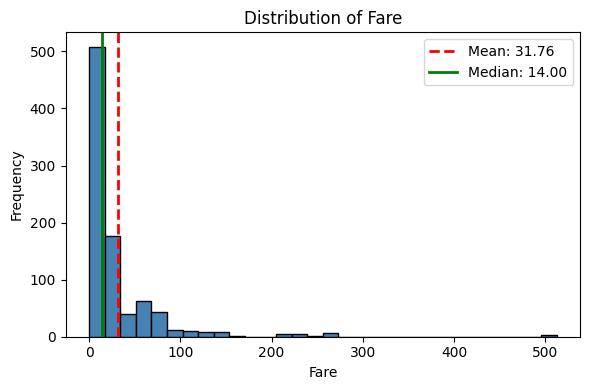

In [240]:
plot_numeric_histogram(titanic_df, "Fare")

Histogram zmiennej Fare jest prawostronnie skośny, większość pasażerów decydowała się na tańsze bilety.

In [241]:
def plot_categorical_column(df, column_name):
    # count occurrences of each category
    counts = df[column_name].value_counts()

    plt.figure(figsize=(6, 4))
    counts.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()

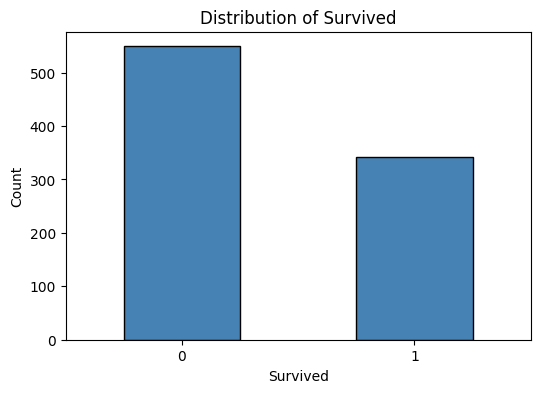

In [242]:
plot_categorical_column(titanic_df, "Survived")

Pasażerowie, którzy nie przeżyli katastrofy stanowią większą grupę od ocalałych.

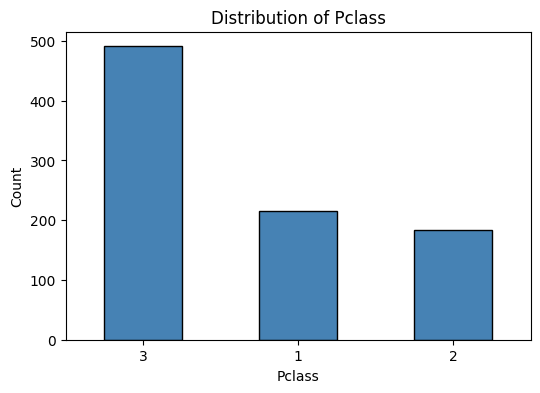

In [243]:
plot_categorical_column(titanic_df, "Pclass")

Największa grupa pasażerów podróżowała w klasie 3. Liczba pasażerów klasy 1 i 2 są do siebie zbliżone.

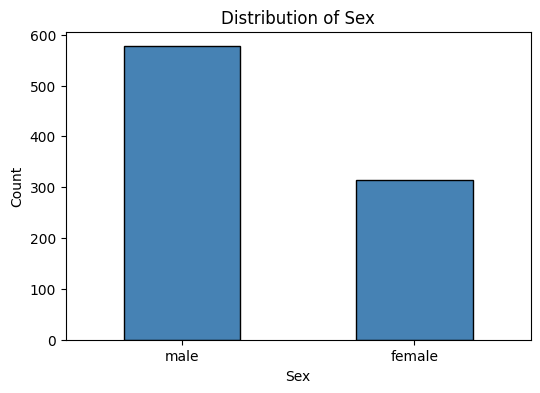

In [244]:
plot_categorical_column(titanic_df, "Sex")

Większość podróżujących to byli mężczyźni.

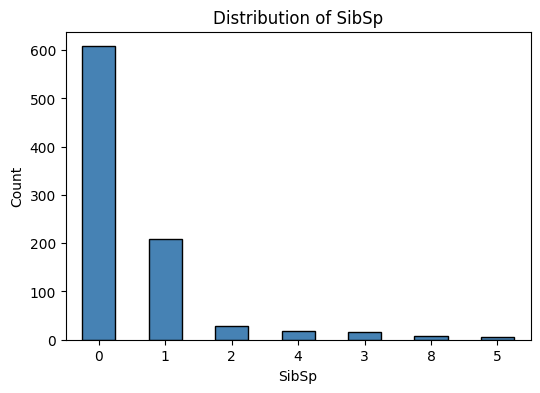

In [245]:
plot_categorical_column(titanic_df, "SibSp")

Rozkład zmiennej SibSp jest prawostronnie skośny - większość pasażerów podróżowała bez rodzeństwa czy małżonków na pokładzie.

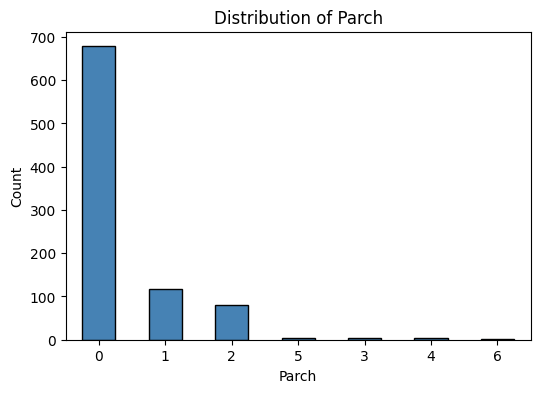

In [246]:
plot_categorical_column(titanic_df, "Parch")

Rozkład zmiennej Parch jest prawostronnie skośny - najwięcej pasażerów podróżowało bez rodziców/bez dzieci.

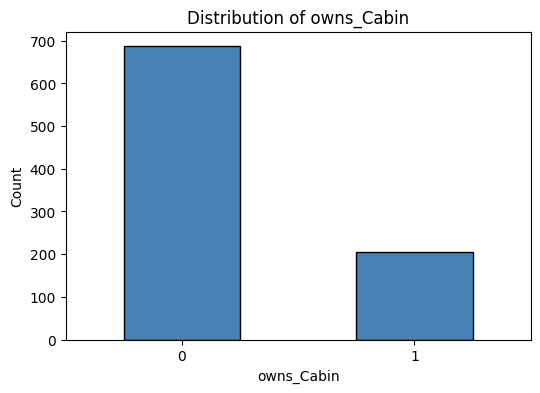

In [247]:
plot_categorical_column(titanic_df, "owns_Cabin")

Większość pasażerów podróżowało nie posiadając przypisanej do siebie kabiny.

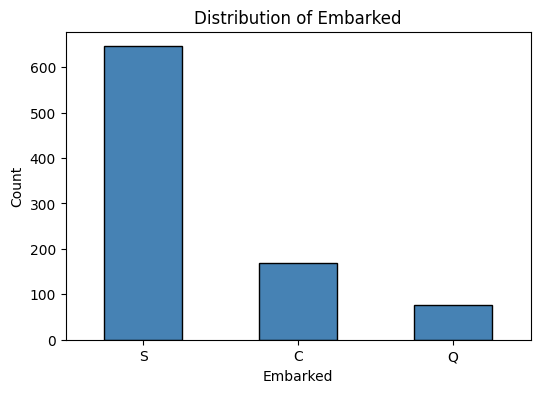

In [248]:
plot_categorical_column(titanic_df, "Embarked")

Większość pasażerów wyruszała z portu Southampton.

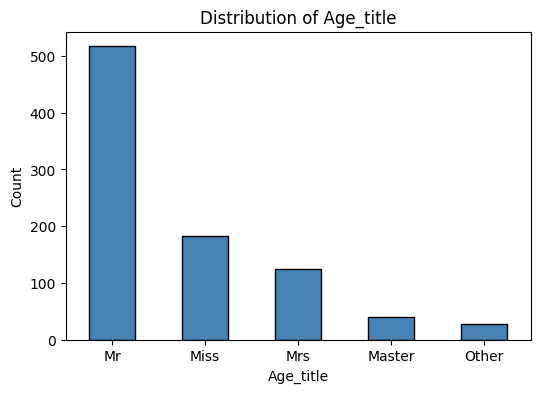

In [249]:
main_titles = ["Mr", "Mrs", "Miss", "Master"]
titanic_df['Age_title'] = titanic_df['Age_title'].apply(lambda x: x if x in main_titles else "Other")
plot_categorical_column(titanic_df, "Age_title")

Większość pasażerów to mężczyźni w średnim wieku (ok.30)

In [250]:
def categorical_and_charges(df, categorical_column):
    """
    Plots a boxplot showing the distribution of 'charges' across categories in the given column.
    Parameters:
        df (pandas.DataFrame): The DataFrame with the data.
        categorical_column (str): The name of the categorical column.
    Returns:
        None. Displays the boxplot.
    """
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=categorical_column, y='Survived')
    plt.title(f'Survived by {categorical_column}')
    plt.xlabel(categorical_column)
    plt.ylabel('Survived')
    plt.tight_layout()
    plt.show()

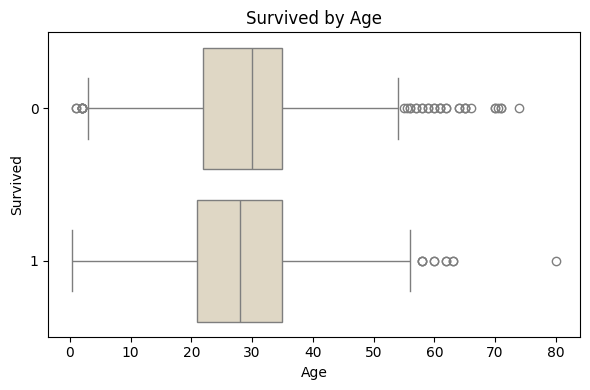

In [251]:
titanic_df['Survived'] = titanic_df['Survived'].astype('category')

categorical_and_charges(titanic_df, "Age")

Mediany wieku w obu grupach Survived są do siebie zbliżone - większość pasażerów mieści się w przedziale ok.20-35 lat. Można zauważyć w obu grupach także wartości odstające. Szczególnie dużo jest ich w grupie Survived = 0 - można sądzić, że starsze osoby miały mniejsze szanse na ewakuację.



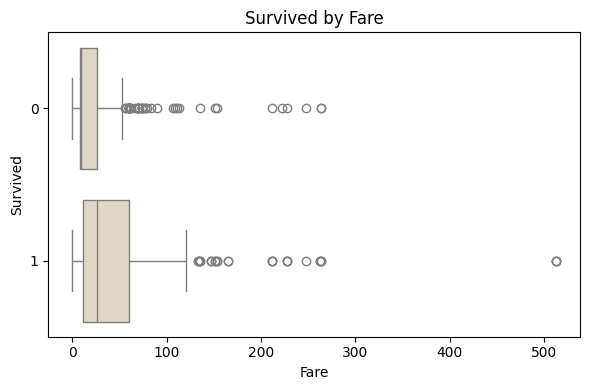

In [252]:
categorical_and_charges(titanic_df, "Fare")

Osoby, które przetrwały mają większą medianę kosztów za bilet. Można też zauważyć, że szerokość pudełka jest większa, co oznacza większe zróżnicowanie kosztów biletów ocalałych. W obu grupach występuje sporo wartości odstających - są to osoby, któe zapłaciły zdecydowanie więcej za bilet (prawdopodobnie podróżujący klasą 1).

In [253]:
def bar_by_survived(df = titanic_df, column_name = "Sex", y= "Survived"):
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=y, hue = column_name)
    plt.title(f'Distribution of {y} by {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()

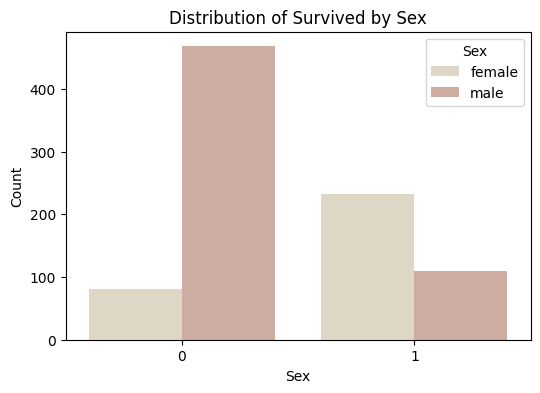

In [254]:
bar_by_survived()

Wśród pasażerów, którzy przeżyli większość stanowią kobiety. Może to byś spowodowane faktem, że zazwyczaj ewakuacja kobiet i dzieci stanowi priorytet.

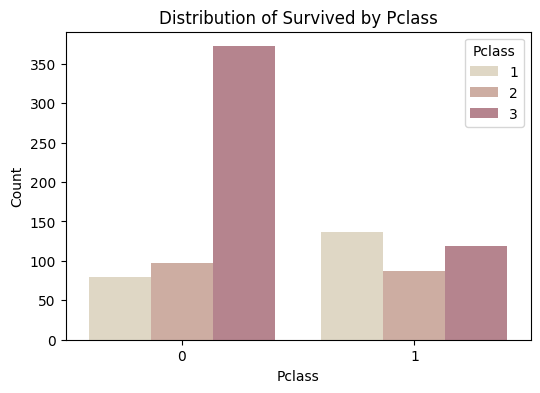

In [255]:
bar_by_survived(column_name="Pclass")

Można zauważyć, że większość ocalałych podróżowała klasą 1. Grupa podróżująca klasą 3 stanowiła największą część wszystkich pasażerów, co także należy brać pod uwagę.
Wniosek dot. korelacji pomiędzy ceną biletu a prawdopodobieństwem przeżycia (box-plot Survived by Fare) pokrywa się z powyższym wykresem.

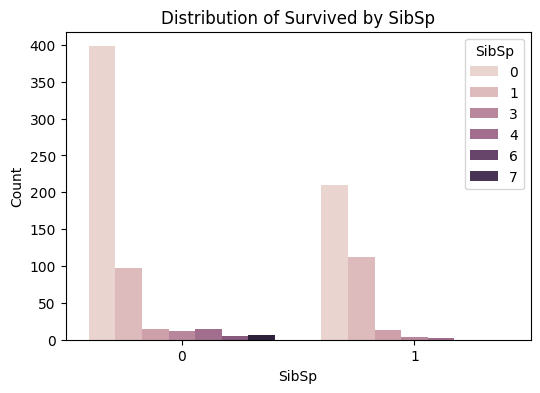

In [256]:
bar_by_survived(column_name="SibSp")

Kształt wykresów dla obu grup jest bardzo podobny, wśród osób, które przetrwały jak i u tych, którym się to nie udało, najliczniejszą grupą jest grupa podróżujących samotnie. Warto jednak zauważyć, że podróżników z jedną osobą towarzyszącą jest więcej wśród ocalałych. Większe grupy miały mniejsze szanse na przeżycie.

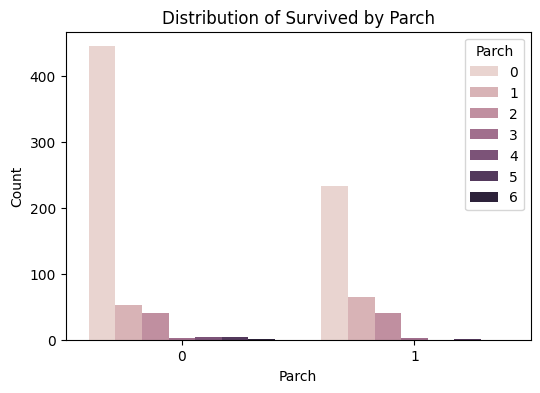

In [257]:
bar_by_survived(column_name="Parch")

Wykres analogiczny do wykresu Distribution of Survived by SibSp. Największą częścią podróżujących w obu grupach stanowili samotni podróżnicy. Można jednak zauważyć, że małe rodziny (2-3 osobowe) stanowiły większą część wśród ocalałych niż w grupie nieocalałych.

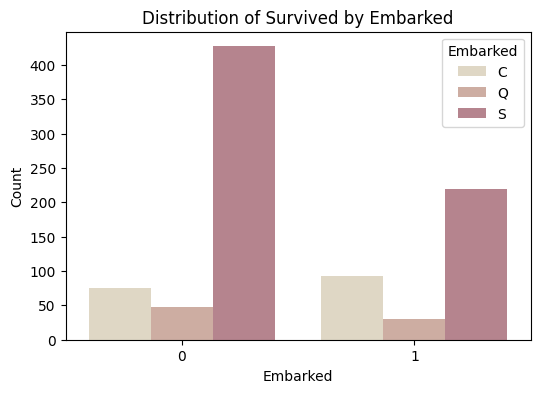

In [258]:
bar_by_survived(column_name="Embarked")

Analizując powyższy wykres można zauważyć, że pasażerowie rozpoczynający podróż w porcie Cherbourg (C) stanowili większą grupę wśród ocalałych niż nieocalałych.

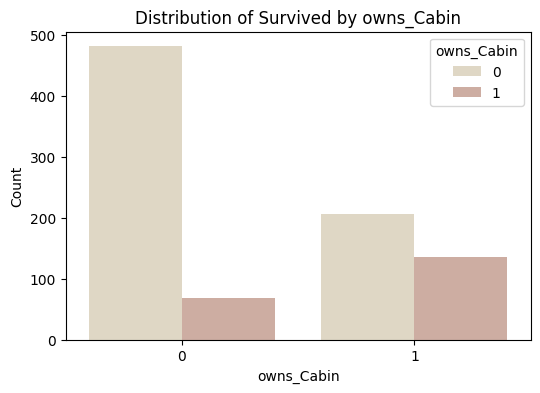

In [259]:
bar_by_survived(column_name="owns_Cabin")

Zdecydowana większość pasażerów posiadających przypisaną do siebie kabinę należałą do grupy osób, któe przeżyły. Jest to prawdopodobnie również powiązane z kosztem biletu oraz klasą, którą pasażer podrózował.

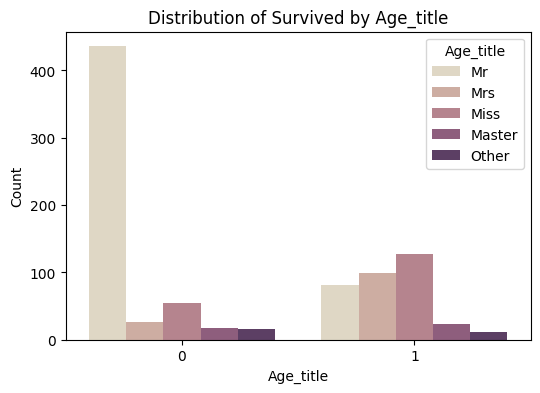

In [260]:
bar_by_survived(column_name="Age_title")

Z powyższego wykresu wynika, że kobiety oraz dzieci rzeczywiście miały większą szansę na przeżycie.

In [261]:
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,owns_Cabin,Age_title
PassengerId,,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S,0,Mr
2,1,1,female,38.0,1,0,71.2833,C,1,Mrs
3,1,3,female,26.0,0,0,7.9250,S,0,Miss
4,1,1,female,35.0,1,0,53.1000,S,1,Mrs
5,0,3,male,35.0,0,0,8.0500,S,0,Mr


In [262]:
titanic_df = pd.get_dummies(data=titanic_df, columns=['Sex', 'Embarked', 'Age_title'], dtype=np.int32) # pass in dataframe and columns to one-hot code


In [263]:
mapping = {
    1:3,
    2:2,
    3:1
}

titanic_df['Pclass'] = titanic_df['Pclass'].map(mapping).astype(int)

titanic_df['Survived'] = titanic_df['Survived'].astype(int)

In [264]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Survived          891 non-null    int64  
 1   Pclass            891 non-null    int64  
 2   Age               891 non-null    float64
 3   SibSp             891 non-null    int64  
 4   Parch             891 non-null    int64  
 5   Fare              891 non-null    float64
 6   owns_Cabin        891 non-null    int64  
 7   Sex_female        891 non-null    int32  
 8   Sex_male          891 non-null    int32  
 9   Embarked_C        891 non-null    int32  
 10  Embarked_Q        891 non-null    int32  
 11  Embarked_S        891 non-null    int32  
 12  Age_title_Master  891 non-null    int32  
 13  Age_title_Miss    891 non-null    int32  
 14  Age_title_Mr      891 non-null    int32  
 15  Age_title_Mrs     891 non-null    int32  
 16  Age_title_Other   891 non-null    int32  
dtypes:

In [265]:
def plot_correlation_matrix(df):
    """
    Plots a heatmap showing the correlation matrix for numeric columns in the DataFrame.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing numeric data.
    Returns:
        None. Displays the correlation heatmap.
    """
    # compute correlation matrix only for numeric columns
    corr = df.corr(numeric_only=True)

    # fmt=".2f" rounds the number to 0.01
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

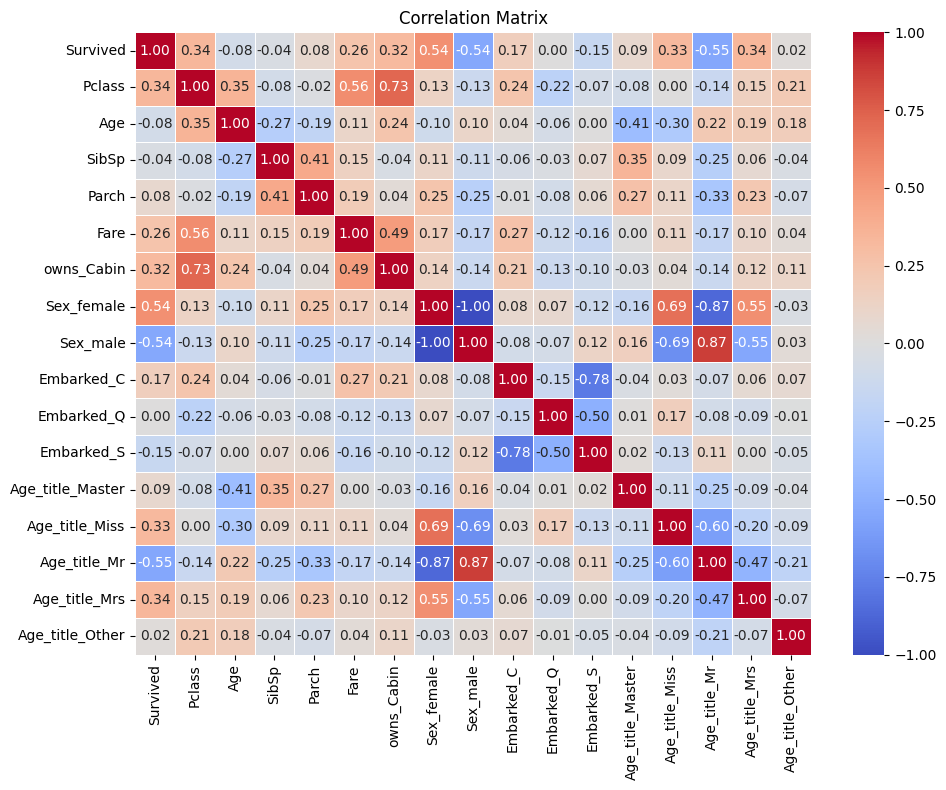

In [266]:
plot_correlation_matrix(titanic_df)

Powyższa heatmapa pozwala określić jak silnie cechy liczbowe są ze sobą powiązane. Najważniejszym czynnikiem powiązanym z szansą na przeżycie jest płeć - Sex_female jest silnie pozytywnie skorelowana ze zmienną Survived. Warto zwrócić także uwagę na zmienne Age_title_Miss oraz Age_title_Mrs - korelacja tych cech ze zmienną Survived potwierdza, że to kobiety i dziewczynki najczęściej były wśród ocalałych.
Kolejną ważną zmienną jest Pclass -  można zauważyć, że im wyższa klasa, tym większe szanse na przeżycie mieli pasażerowie. Ta cecha jest silnie skorelowana ze zmiennymi Fare oraz owns_Cabin, co wyjaśnia dlaczego te zmienne również mają duży wpływ na zmienną Survived.